# Executive Summary

**Open this notebook first.** A ~30-second tour of the full risk analysis: loads cached data, prints the headline metrics table, and renders the four charts referenced in the README. Every detailed step (data ingestion, VaR derivations, Monte Carlo convergence, SLSQP optimization, Kupiec backtesting) is in the numbered notebooks 01-06.

**Portfolio:** equal-weight basket of AAPL, MSFT, GOOGL, JPM, BRK-B (equities), GLD (gold), TLT (long Treasuries), SPY (S&P 500 benchmark).
**Window:** 2019-01-02 to 2024-12-30 (1,508 daily observations, 6 years spanning four distinct market regimes).
**Notional:** $1,000,000.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize

# Reproducibility — same seed as the detailed Monte Carlo notebook
SEED            = 42
np.random.seed(SEED)

# Constants
TRADING_DAYS    = 252
RF              = 0.045
PORTFOLIO_VALUE = 1_000_000
MAX_WEIGHT      = 0.25       # box constraint for the recommended portfolio
FIG_DIR         = "../reports/figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Load cached inputs (produced by notebooks 01 and 02)
prices            = pd.read_csv("../data/prices.csv",            index_col=0, parse_dates=True)
log_returns       = pd.read_csv("../data/log_returns.csv",       index_col=0, parse_dates=True)
portfolio_returns = pd.read_csv("../data/portfolio_returns.csv", index_col=0, parse_dates=True).squeeze()

tickers       = list(prices.columns)
n_assets      = len(tickers)
weights       = np.full(n_assets, 1 / n_assets)
annual_returns= log_returns.mean() * TRADING_DAYS
cov_matrix    = log_returns.cov()  * TRADING_DAYS

print(f"Loaded {len(prices):,} days of data, {n_assets} assets, {prices.index[0].date()} → {prices.index[-1].date()}")

Loaded 1,509 days of data, 8 assets, 2019-01-02 → 2024-12-30


## Headline metrics

In [2]:
# Portfolio-level stats
port_ret   = annual_returns.dot(weights)
port_vol   = np.sqrt(weights.T @ cov_matrix @ weights)
sharpe     = (port_ret - RF) / port_vol

# Historical VaR/CVaR
def var_cvar(r, alpha):
    var = np.percentile(r, alpha * 100)
    cvar = r[r <= var].mean()
    return var, cvar

hv95, hc95 = var_cvar(portfolio_returns.values, 0.05)
hv99, hc99 = var_cvar(portfolio_returns.values, 0.01)

# Parametric VaR/CVaR
mu, sd = portfolio_returns.mean(), portfolio_returns.std()
pv95 = mu + norm.ppf(0.05) * sd; pc95 = mu - sd * norm.pdf(norm.ppf(0.05)) / 0.05
pv99 = mu + norm.ppf(0.01) * sd; pc99 = mu - sd * norm.pdf(norm.ppf(0.01)) / 0.01

# Monte Carlo VaR/CVaR (seed=42, 10k paths)
np.random.seed(SEED)
L = np.linalg.cholesky(log_returns.cov().values)
sim = (np.random.standard_normal((10_000, n_assets)) @ L.T + log_returns.mean().values) @ weights
mv95, mc95 = var_cvar(sim, 0.05)
mv99, mc99 = var_cvar(sim, 0.01)

def d(r):  return f"${abs(r) * PORTFOLIO_VALUE:>8,.0f}"
metrics = pd.DataFrame({
    "Historical":  [d(hv95), d(hc95), d(hv99), d(hc99)],
    "Parametric":  [d(pv95), d(pc95), d(pv99), d(pc99)],
    "Monte Carlo": [d(mv95), d(mc95), d(mv99), d(mc99)],
}, index=["95% VaR", "95% CVaR", "99% VaR", "99% CVaR"])

print("=== Portfolio (equal-weight, $1M notional) ===")
print(f"Annual return:       {port_ret:.2%}")
print(f"Annual volatility:   {port_vol:.2%}")
print(f"Sharpe (RF={RF:.1%}):    {sharpe:.3f}")
print("\n=== One-day VaR / CVaR (loss; lower = worse) ===")
print(metrics.to_string())
print(f"\nFat-tail gap (Hist 99% VaR − Param 99% VaR):  ${(abs(hv99) - abs(pv99)) * PORTFOLIO_VALUE:,.0f}")

=== Portfolio (equal-weight, $1M notional) ===
Annual return:       16.71%
Annual volatility:   16.83%
Sharpe (RF=4.5%):    0.725

=== One-day VaR / CVaR (loss; lower = worse) ===
         Historical Parametric Monte Carlo
95% VaR   $  15,531  $  16,775   $  16,689
95% CVaR  $  25,284  $  21,205   $  21,022
99% VaR   $  29,146  $  24,000   $  24,017
99% CVaR  $  43,829  $  27,592   $  27,734

Fat-tail gap (Hist 99% VaR − Param 99% VaR):  $5,146


## Hero chart 1 — cumulative growth of $1, all 8 assets

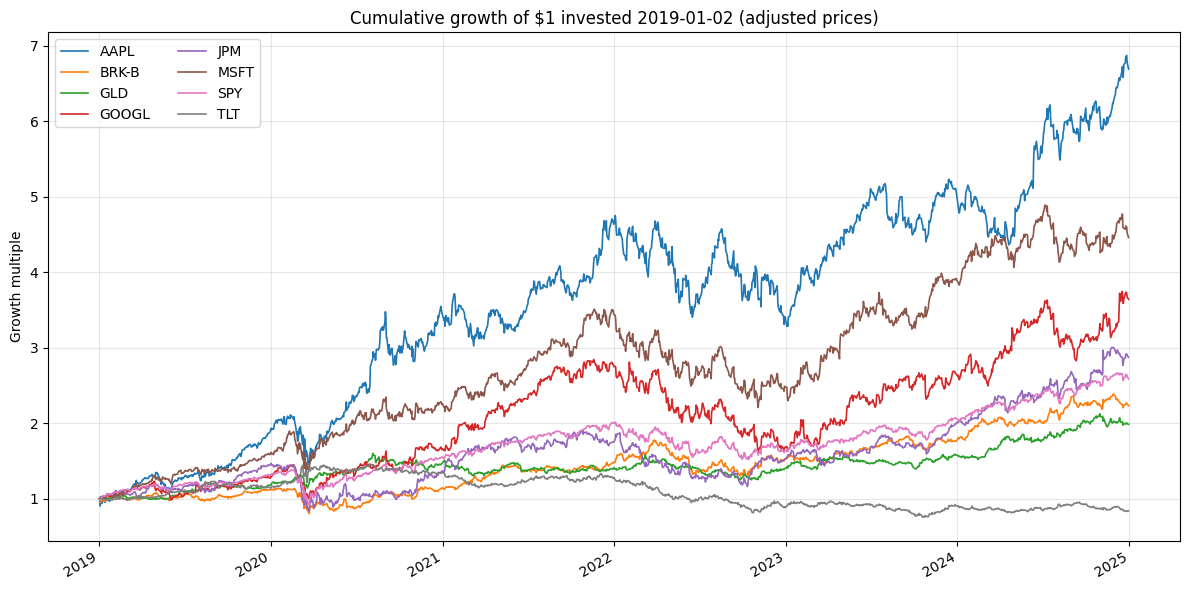

In [3]:
cum = prices / prices.iloc[0]

fig, ax = plt.subplots(figsize=(12, 6))
cum.plot(ax=ax, linewidth=1.2)
ax.set_title("Cumulative growth of $1 invested 2019-01-02 (adjusted prices)")
ax.set_ylabel("Growth multiple")
ax.set_xlabel("")
ax.grid(alpha=0.3)
ax.legend(loc="upper left", ncol=2)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/cumulative_growth.png", dpi=150, bbox_inches="tight")
plt.show()

## Hero chart 2 — rolling 30-day correlation, selected pairs

Correlations are NOT static. The SPY-TLT pair (classic 'stocks vs bonds') is reliably negative through 2019-2021, then flips positive in 2022 as aggressive rate hikes hurt both. This is the visual justification for why parametric VaR (which assumes a static covariance matrix) misses fat-tail risk.

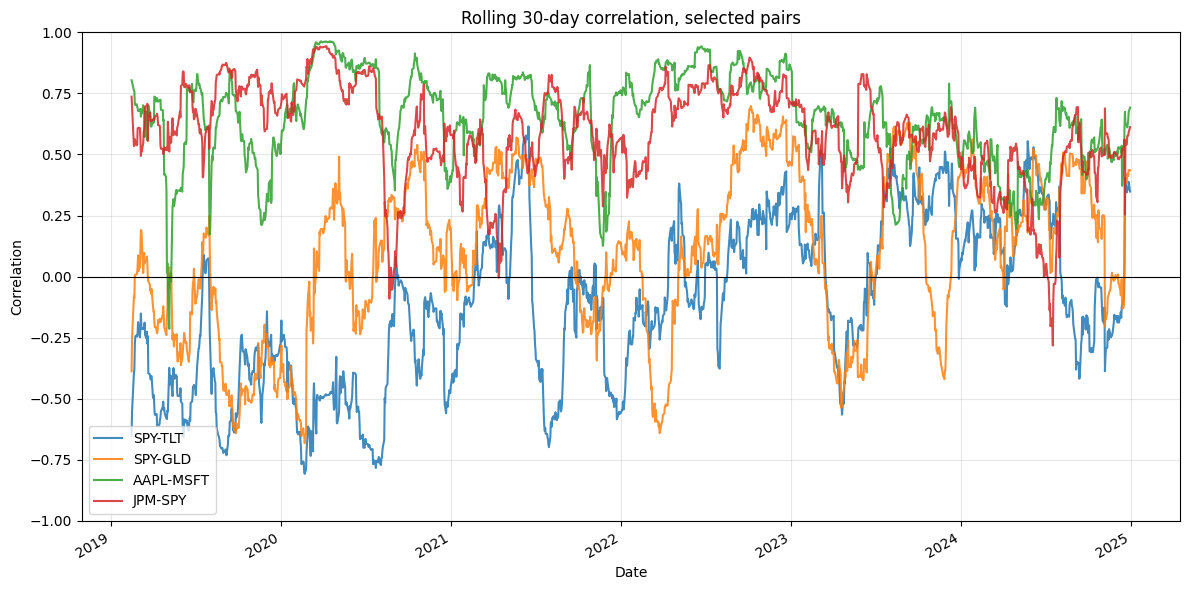

In [4]:
pairs   = [("SPY","TLT"), ("SPY","GLD"), ("AAPL","MSFT"), ("JPM","SPY")]
window  = 30

rolling = pd.DataFrame(index=log_returns.index)
for a, b in pairs:
    rolling[f"{a}-{b}"] = log_returns[a].rolling(window).corr(log_returns[b])
rolling = rolling.dropna()

fig, ax = plt.subplots(figsize=(12, 6))
rolling.plot(ax=ax, alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title(f"Rolling {window}-day correlation, selected pairs")
ax.set_ylabel("Correlation")
ax.set_ylim(-1, 1)
ax.grid(alpha=0.3)
ax.legend(loc="lower left")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/rolling_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

## Hero chart 3 — daily return distribution with 99% VaR thresholds

The visible left tail beyond the parametric VaR line is the loss exposure the Normal model misses. Jarque-Bera in notebook 03 confirms: returns have skewness -0.54 and excess kurtosis +11.6, rejecting Normality at p ≈ 0.

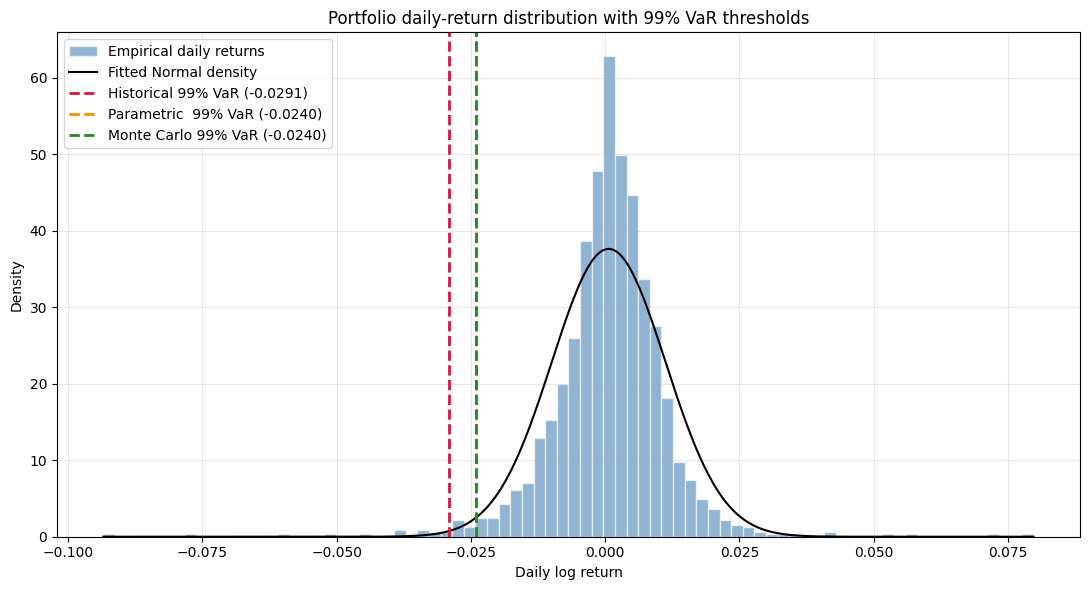

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.hist(portfolio_returns, bins=80, density=True, alpha=0.6, color="steelblue",
        edgecolor="white", label="Empirical daily returns")
xs = np.linspace(portfolio_returns.min(), portfolio_returns.max(), 400)
ax.plot(xs, norm.pdf(xs, mu, sd), color="black", linewidth=1.5, label="Fitted Normal density")
ax.axvline(hv99, color="crimson",    linestyle="--", linewidth=2,
           label=f"Historical 99% VaR ({hv99:.4f})")
ax.axvline(pv99, color="darkorange", linestyle="--", linewidth=2,
           label=f"Parametric  99% VaR ({pv99:.4f})")
ax.axvline(mv99, color="forestgreen",linestyle="--", linewidth=2,
           label=f"Monte Carlo 99% VaR ({mv99:.4f})")
ax.set_title("Portfolio daily-return distribution with 99% VaR thresholds")
ax.set_xlabel("Daily log return")
ax.set_ylabel("Density")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/return_distribution_var.png", dpi=150, bbox_inches="tight")
plt.show()

## Hero chart 4 — efficient frontier with SLSQP-optimised portfolios

Random Dirichlet cloud (coloured by Sharpe) gives the visual frontier; SLSQP analytically solves for the optimal portfolios. The **green star** is the recommendation — max-Sharpe with a 25% per-asset cap. The gold star (unconstrained max-Sharpe) achieves a marginally higher Sharpe but concentrates ~90% in just AAPL + GLD, which is brittle in practice.

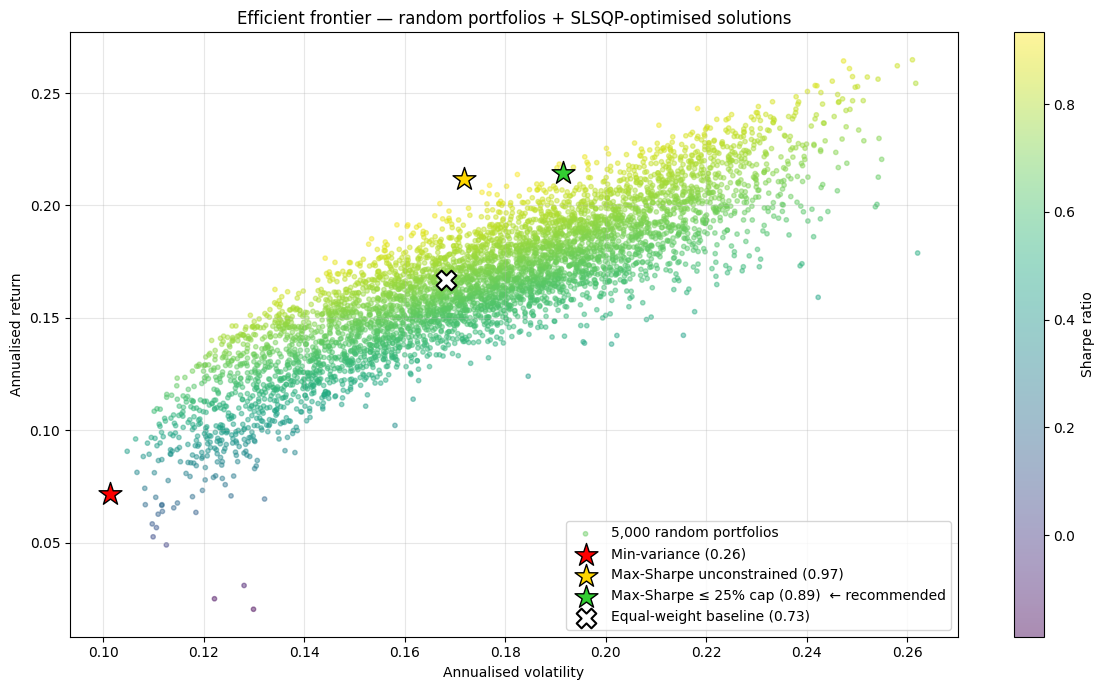


Recommended portfolio (max-Sharpe with ≤ 25% per asset):
  AAPL    25.00%
  BRK-B    4.65%
  GLD     25.00%
  GOOGL    5.20%
  JPM     15.15%
  MSFT    25.00%
  SPY      0.00%
  TLT      0.00%


In [6]:
def portfolio_stats(w):
    r = annual_returns.dot(w)
    v = np.sqrt(w.T @ cov_matrix @ w)
    return r, v, (r - RF) / v

def neg_sharpe(w): return -portfolio_stats(w)[2]
def vol(w):       return np.sqrt(w.T @ cov_matrix @ w)

# Random sampling
n_random = 5_000
results = np.zeros((3, n_random))
for i in range(n_random):
    w = np.random.dirichlet(np.ones(n_assets))
    results[:, i] = portfolio_stats(w)

# SLSQP optimisation
x0      = weights
eq_cons = ({"type": "eq", "fun": lambda w: w.sum() - 1.0},)
mv_res  = minimize(vol,        x0, method="SLSQP", bounds=[(0,1)]*n_assets,           constraints=eq_cons)
unc_res = minimize(neg_sharpe, x0, method="SLSQP", bounds=[(0,1)]*n_assets,           constraints=eq_cons)
box_res = minimize(neg_sharpe, x0, method="SLSQP", bounds=[(0,MAX_WEIGHT)]*n_assets,  constraints=eq_cons)

mv_s  = portfolio_stats(mv_res.x)
unc_s = portfolio_stats(unc_res.x)
box_s = portfolio_stats(box_res.x)
eq_s  = portfolio_stats(weights)

fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(results[1], results[0], c=results[2], cmap="viridis", alpha=0.45, s=10,
                label=f"{n_random:,} random portfolios")
plt.colorbar(sc, ax=ax, label="Sharpe ratio")
ax.scatter(*mv_s[1::-1],  marker="*", s=300, color="red",       edgecolor="black", linewidth=1, zorder=5, label=f"Min-variance ({mv_s[2]:.2f})")
ax.scatter(*unc_s[1::-1], marker="*", s=300, color="gold",      edgecolor="black", linewidth=1, zorder=5, label=f"Max-Sharpe unconstrained ({unc_s[2]:.2f})")
ax.scatter(*box_s[1::-1], marker="*", s=300, color="limegreen", edgecolor="black", linewidth=1, zorder=5, label=f"Max-Sharpe ≤ {MAX_WEIGHT:.0%} cap ({box_s[2]:.2f})  ← recommended")
ax.scatter(*eq_s[1::-1],  marker="X", s=200, color="white",     edgecolor="black", linewidth=1.5, zorder=5, label=f"Equal-weight baseline ({eq_s[2]:.2f})")
ax.set_xlabel("Annualised volatility")
ax.set_ylabel("Annualised return")
ax.set_title("Efficient frontier — random portfolios + SLSQP-optimised solutions")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/efficient_frontier.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nRecommended portfolio (max-Sharpe with ≤ {MAX_WEIGHT:.0%} per asset):")
for t, w in zip(tickers, box_res.x):
    print(f"  {t:7s} {w:6.2%}")

## Where to go next

- **`notebooks/01_data_ingestion.ipynb`** — pulls and cleans 6 years of adjusted prices from yfinance
- **`notebooks/02_portfolio_metrics.ipynb`** — covariance matrix, rolling correlations, equal-weight baseline
- **`notebooks/03_var_analysis.ipynb`** — Historical & Parametric VaR, Q-Q + Jarque-Bera normality test, regime stress slices
- **`notebooks/04_monte_carlo.ipynb`** — Cholesky-based Monte Carlo + convergence check at 1k/5k/10k/25k/50k paths
- **`notebooks/05_efficient_frontier.ipynb`** — SLSQP with unconstrained + box-constrained max-Sharpe
- **`notebooks/06_backtesting.ipynb`** — Kupiec proportion-of-failures test on a held-out year
- **`reports/risk_report.md`** — written report for a non-technical reader